### Carry out machine-learning-based classification approach using labeled snipped 
Author: Charlotte Bez

Date: April 2025

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

In [1]:
train_file_path = "Input_Manually_Labeled_Snippets.xlsx"  
df_train = pd.read_excel(train_file_path)

test_file_path = "Output_Few_Shot_Prompt.xlsx"
df_test = pd.read_excel(test_file_path)

print("df_test columns:", df_test.columns)
print("df_train columns:", df_train.columns)

if "Article_Snippet" not in df_test.columns:
    raise ValueError("The column 'Article_Snippet' is missing from the classification dataset.")
if "snippet" not in df_train.columns or "actor_class" not in df_train.columns:
    raise ValueError("The training dataset is missing required columns: 'snippet' and 'actor_class'.")

training_data = [(row["snippet"], row["actor_class"].capitalize()) for _, row in df_train.iterrows()]
print(f"Total examples in training_data: {len(training_data)}")

df_test columns: Index(['ID', 'Date', 'Article_Snippet'], dtype='object')
df_train columns: Index(['doc_ID', 'snippet', 'actor_class', 'year', 'sentiment', 'cluster',
       'actor_class_justification', 'Unnamed: 7'],
      dtype='object')
Total examples in training_data: 131


In [2]:
file_path_test = "Output_Few_Shot_Prompt.xlsx"  
df_test = pd.read_excel(file_path_test)

if "Article_Snippet" not in df_test.columns:
    raise ValueError("The column 'Article_Snippet' is missing from the dataset.")

file_path_train = "Input_Manually_Labeled_Snippets.xlsx"  
df_train = pd.read_excel(file_path_train)

if "snippet" not in df_train.columns or "actor_class" not in df_train.columns:
    raise ValueError("Columns 'snippet' and 'actor_class' are missing from the training dataset.")

actor_class_definitions = {
    "Ambiguous": """Texts in this group do not take a clear stance or opinion about what a just transition entails. 
    They describe facts, processes, policy developments, or general statements without expressing support, criticism, or specific visions. 
    This includes references to official policies, institutions, agreements, or reports that mention the just transition but do not articulate 
    a position on its desirability, feasibility, or impact.""",
    
    "Sceptic": """Texts in this group express scepticism, doubt, or opposition to phasing out fossil fuels as part of the just transition. They advocate for continued use of coal, oil, or gas, often citing economic, energy security, or employment concerns. This includes arguments that phasing out fossil fuels is unrealistic, harmful to South Africa's economy, or that carbon management strategies should be pursued instead of fossil fuel phaseout.
    Some sceptic texts do not directly oppose the just transition but cast doubt on its feasibility, arguing that South Africa is not institutionally, financially, or politically capable of carrying it out. They highlight risks of job losses, political instability, or economic decline as reasons to delay or reconsider the transition.""",
    
    "Opportunist": """Texts in this group frame the just transition as an opportunity for economic, social, or environmental benefits. They emphasize the potential gains from transitioning to a low-carbon economy, including job creation, economic growth, industrial development, investment attraction, or international leadership. They present the just transition as something desirable and beneficial for the country, the economy, or society.""",
    
    "Realist": """Texts in this group take a pragmatic approach to the just transition, focusing on practical considerations, challenges, and necessary conditions for success. They do not oppose the transition but highlight the real-world barriers and requirements for making it work, such as financial constraints, worker reskilling, government coordination, and balancing energy security. The transition is not framed as inherently good or bad, but as something that requires careful planning, investment, and policy support."""
}

df_train["enhanced_snippet"] = df_train.apply(
    lambda row: f"{row['snippet']} {actor_class_definitions.get(row['actor_class'].capitalize(), '')} Justification: {row['actor_class_justification']}",
    axis=1
)

X_train, y_train = df_train["enhanced_snippet"].fillna(""), df_train["actor_class"].str.capitalize()

def classify_snippet(snippet, pipeline):
    snippet_clean = snippet.strip().lower()
    
    for text, label in zip(df_train["enhanced_snippet"], df_train["actor_class"]):
        text_clean = text.strip().lower()
        if snippet_clean == text_clean:
            return label.capitalize()

    return pipeline.predict([snippet])[0]

models = {
    "Classification_Run_1": make_pipeline(TfidfVectorizer(), MultinomialNB(alpha=0.1)),
    "Classification_Run_2": make_pipeline(TfidfVectorizer(), MultinomialNB(alpha=0.08)),
    "Classification_Run_3": make_pipeline(TfidfVectorizer(), MultinomialNB(alpha=0.07)) 
}

for run_name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    df_test[run_name] = df_test["Article_Snippet"].apply(lambda snippet: classify_snippet(snippet, pipeline))

print(df_test.head())

output_file = "Output_Few_Shot_Prompt_ML.xlsx"
df_test.to_excel(output_file, index=False)

   ID                 Date                                    Article_Snippet  \
0   1  2022-01-05 00:00:00  That, in turn, will help us to explore new inv...   
1   1  2022-01-05 00:00:00  A just energy transition While large-scale ene...   
2   1  2022-01-05 00:00:00  However, it has been accepted that we are not ...   
3   1  2022-01-05 00:00:00  There are many issues that need to be unpacked...   
4   1  2022-01-05 00:00:00  Green hydrogen Green hydrogen has gained momen...   

  Classification_Run_1 Classification_Run_2 Classification_Run_3  
0          Opportunist          Opportunist          Opportunist  
1          Opportunist          Opportunist          Opportunist  
2              Realist              Realist              Realist  
3            Ambiguous            Ambiguous            Ambiguous  
4          Opportunist          Opportunist          Opportunist  


In [3]:
print(df_train["actor_class"].value_counts())

actor_class
opportunist    37
realist        33
sceptic        31
ambiguous      30
Name: count, dtype: int64


In [4]:
print(df_test["Classification_Run_1"].value_counts())
print(df_test["Classification_Run_2"].value_counts())
print(df_test["Classification_Run_3"].value_counts())

Classification_Run_1
Opportunist    1508
Realist         714
Ambiguous       323
Sceptic         202
Name: count, dtype: int64
Classification_Run_2
Opportunist    1479
Realist         723
Ambiguous       332
Sceptic         213
Name: count, dtype: int64
Classification_Run_3
Opportunist    1462
Realist         726
Ambiguous       343
Sceptic         216
Name: count, dtype: int64


In [5]:
output_file = "./Output_Few_Shot_Prompt_ML.xlsx"
df_test.to_excel(output_file, index=False)

output_file

'./Output_Few_Shot_Prompt_ML.xlsx'

In [3]:
print("Predictions for test data distribution:")
for run_name, pipeline in models.items():
    preds = pipeline.predict(X_train)
    print(f"{run_name}: {pd.Series(preds).value_counts()}")

Predictions for test data distribution:


NameError: name 'models' is not defined

If a class is missing here, the model is not predicting it at all.

C:\Users\charlott\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


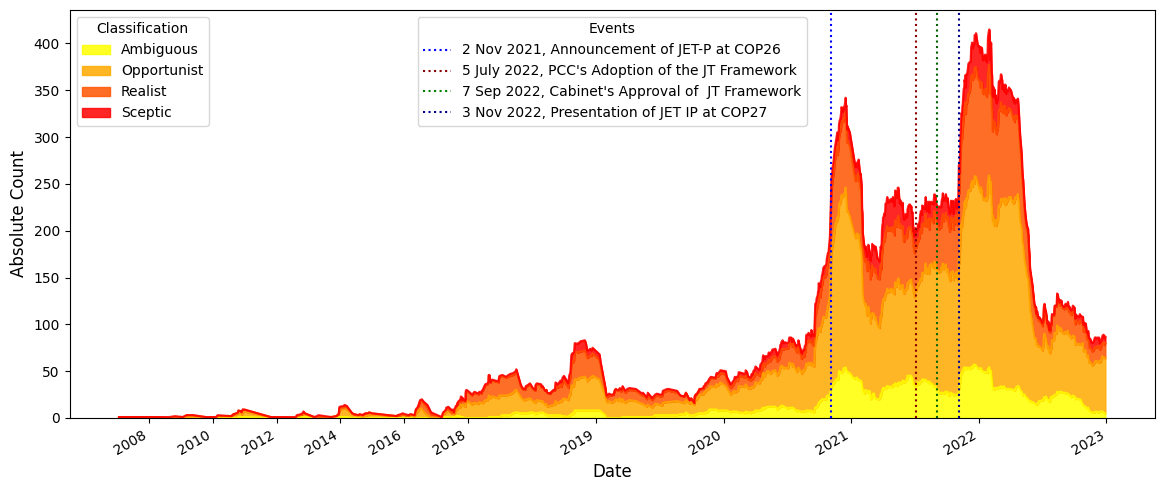

In [4]:
df_test["Date"] = pd.to_datetime(df_test["Date"])

df = df_test

df_grouped_abs = df.groupby(["Date", "Classification_Run_3"]).size().unstack(fill_value=0)

df_absolute_rolling = df_grouped_abs.rolling("90D", min_periods=1).sum()

def transform_date(date):
    ref_date = pd.Timestamp("2018-12-31")
    if date < ref_date:
        return ref_date - (ref_date - date) / 4
    else:
        return date

df_absolute_rolling_transformed = df_absolute_rolling.copy()
df_absolute_rolling_transformed.index = df_absolute_rolling.index.map(transform_date)

fig, ax = plt.subplots(figsize=(14, 6))
df_absolute_rolling_transformed.plot.area(ax=ax, colormap="autumn_r", alpha=0.85)

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Absolute Count", fontsize=12)
ax.legend(title="Classification", loc="upper left")

ticks_pre_2018 = pd.date_range(start="2008-01-01", end="2018-12-31", freq="2YE")
ticks_post_2018 = pd.date_range(start="2018-01-01", end="2024-01-01", freq="1YE")
original_ticks = ticks_pre_2018.union(ticks_post_2018)

transformed_ticks = [transform_date(tick) for tick in original_ticks]

ax.set_xticks(transformed_ticks)
ax.set_xticklabels(original_ticks.strftime("%Y"))

ax.axvline(transform_date(pd.Timestamp("2021-11-02")), color="blue", linestyle="dotted")  
ax.axvline(transform_date(pd.Timestamp("2022-11-03")), color="darkblue", linestyle="dotted")   

ax.axvline(transform_date(pd.Timestamp("2022-09-02")), color="darkgreen", linestyle="dotted")   

ax.axvline(transform_date(pd.Timestamp("2022-07-05")), color="darkred", linestyle="dotted")   


blue_line = mlines.Line2D([], [], color="blue", linestyle="dotted", label="2 Nov 2021, Announcement of JET-P at COP26")
darkblue_line = mlines.Line2D([], [], color="darkblue", linestyle="dotted", label="3 Nov 2022, Presentation of JET IP at COP27")

green_line = mlines.Line2D([], [], color="green", linestyle="dotted", label="7 Sep 2022, Cabinet's Approval of  JT Framework")
darkred_line = mlines.Line2D([], [], color="darkred", linestyle="dotted", label="5 July 2022, PCC's Adoption of the JT Framework")

classification_legend = ax.legend(title="Classification", loc="upper left")
event_legend = ax.legend(handles=[blue_line, darkred_line, green_line, darkblue_line], loc="upper center", title="Events")
ax.add_artist(classification_legend)

plt.show()

In [5]:
df_test["Date"] = pd.to_datetime(df_test["Date"])

df = df_test

df["Year"] = df["Date"].dt.year
df_grouped_yearly = df.groupby(["Year", "Classification_Run_3"]).size().unstack(fill_value=0)

latex_table = df_grouped_yearly.to_latex(index=True, caption="Frequency Distribution of Categories per Year", label="tab:category_distribution")

latex_table

'\\begin{table}\n\\caption{Frequency Distribution of Categories per Year}\n\\label{tab:category_distribution}\n\\begin{tabular}{lrrrr}\n\\toprule\nClassification_Run_3 & Ambiguous & Opportunist & Realist & Sceptic \\\\\nYear &  &  &  &  \\\\\n\\midrule\n2008 & 0 & 1 & 0 & 0 \\\\\n2009 & 0 & 2 & 0 & 1 \\\\\n2010 & 0 & 2 & 3 & 0 \\\\\n2011 & 1 & 12 & 3 & 1 \\\\\n2012 & 0 & 1 & 0 & 0 \\\\\n2013 & 1 & 5 & 1 & 1 \\\\\n2014 & 1 & 10 & 1 & 4 \\\\\n2015 & 0 & 11 & 5 & 0 \\\\\n2016 & 0 & 4 & 0 & 1 \\\\\n2017 & 0 & 12 & 13 & 4 \\\\\n2018 & 3 & 33 & 18 & 6 \\\\\n2019 & 17 & 86 & 72 & 13 \\\\\n2020 & 15 & 67 & 34 & 7 \\\\\n2021 & 80 & 313 & 136 & 39 \\\\\n2022 & 147 & 522 & 277 & 101 \\\\\n2023 & 78 & 381 & 163 & 38 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

In [6]:
df_classification_relative = (df_grouped_abs.mean() / df_grouped_abs.mean().sum()) * 100

print(df_classification_relative.sort_values(ascending=False))

Classification_Run_3
Opportunist    53.221696
Realist        26.428831
Ambiguous      12.486349
Sceptic         7.863123
dtype: float64


In [7]:
df["Date"] = pd.to_datetime(df["Date"])

event_dates = [pd.Timestamp("2021-11-02"), pd.Timestamp("2022-11-03")]

month_windows = [1, 2, 3, 4, 5, 6]

all_results = {}

for event_date in event_dates:
    all_results[event_date] = {}

    for months in month_windows:
        pre_start = event_date - pd.DateOffset(months=months)
        pre_end = event_date
        post_start = event_date
        post_end = event_date + pd.DateOffset(months=months)

        df_pre = df[(df["Date"] >= pre_start) & (df["Date"] < pre_end)]
        df_post = df[(df["Date"] >= post_start) & (df["Date"] < post_end)]

        pre_counts = df_pre["Classification_Run_3"].value_counts()
        post_counts = df_post["Classification_Run_3"].value_counts()

        all_categories = pre_counts.index.union(post_counts.index)
        pre_counts = pre_counts.reindex(all_categories, fill_value=0)
        post_counts = post_counts.reindex(all_categories, fill_value=0)

        observed_counts = {category: [pre_counts[category], post_counts[category]] for category in all_categories}

        total_pre = pre_counts.sum()
        total_post = post_counts.sum()

        expected_counts = {
            category: [pre_counts[category], (pre_counts[category] / total_pre) * total_post] 
            if total_pre > 0 else [0, 0] 
            for category in all_categories
        }

        normalized_expected_counts = {}
        for category in all_categories:
            scaling_factor = sum(observed_counts[category]) / sum(expected_counts[category]) if sum(expected_counts[category]) > 0 else 1
            normalized_expected_counts[category] = [val * scaling_factor for val in expected_counts[category]]

        chi2_results = {}
        for category in all_categories:
            if sum(normalized_expected_counts[category]) > 0:
                chi2, p_value = stats.chisquare(f_obs=observed_counts[category], f_exp=normalized_expected_counts[category])
                chi2_results[category] = {"Chi2": chi2, "P-Value": p_value}

        interpretation_results = {}
        for category, results in chi2_results.items():
            chi2_stat = results["Chi2"]
            p_value = results["P-Value"]

            if p_value < 0.05:
                interpretation = f"The '{category}' classification has changed significantly post-event (p < 0.05)."
            else:
                interpretation = f"No statistically significant change in '{category}' classification post-event (p >= 0.05)."

            interpretation_results[category] = {
                "Chi2": chi2_stat,
                "P-Value": p_value,
                "Interpretation": interpretation
            }

        all_results[event_date][f"{months}-month window"] = {
            "Chi-Square Results": chi2_results,
            "Interpretation": interpretation_results,
            "Observed Counts": observed_counts
        }

all_results

{Timestamp('2021-11-02 00:00:00'): {'1-month window': {'Chi-Square Results': {'Opportunist': {'Chi2': 0.08928571428571429,
     'P-Value': 0.7650871933583798},
    'Realist': {'Chi2': 0.8928571428571428, 'P-Value': 0.3447042220069577},
    'Ambiguous': {'Chi2': 0.5, 'P-Value': 0.47950012218695337},
    'Sceptic': {'Chi2': 0.0625, 'P-Value': 0.8025873486341526}},
   'Interpretation': {'Opportunist': {'Chi2': 0.08928571428571429,
     'P-Value': 0.7650871933583798,
     'Interpretation': "No statistically significant change in 'Opportunist' classification post-event (p >= 0.05)."},
    'Realist': {'Chi2': 0.8928571428571428,
     'P-Value': 0.3447042220069577,
     'Interpretation': "No statistically significant change in 'Realist' classification post-event (p >= 0.05)."},
    'Ambiguous': {'Chi2': 0.5,
     'P-Value': 0.47950012218695337,
     'Interpretation': "No statistically significant change in 'Ambiguous' classification post-event (p >= 0.05)."},
    'Sceptic': {'Chi2': 0.0625,
 

In [8]:
event_date = pd.Timestamp("2021-11-03")
pre_start = event_date - pd.DateOffset(months=6)
pre_end = event_date
post_start = event_date
post_end = event_date + pd.DateOffset(months=6)

df_pre = df[(df["Date"] >= pre_start) & (df["Date"] < pre_end)]
df_post = df[(df["Date"] >= post_start) & (df["Date"] < post_end)]

pre_counts = df_pre["Classification_Run_3"].value_counts()
post_counts = df_post["Classification_Run_3"].value_counts()

all_categories = pre_counts.index.union(post_counts.index)
pre_counts = pre_counts.reindex(all_categories, fill_value=0)
post_counts = post_counts.reindex(all_categories, fill_value=0)

total_pre = sum(pre_counts)
total_post = sum(post_counts)

relative_shift = {}
for category in all_categories:
    observed_pre = pre_counts[category] / total_pre
    observed_post = post_counts[category] / total_post

    shift = (observed_post - observed_pre) * 100

    relative_shift[category] = shift

total_shift = sum(relative_shift.values())
relative_shift = {cat: shift - (total_shift / len(all_categories)) for cat, shift in relative_shift.items()}

relative_shift

{'Opportunist': -6.685477369572732,
 'Realist': -0.6053495335713461,
 'Ambiguous': 2.9274156397558455,
 'Sceptic': 4.363411263388232}

In [9]:
event_date = pd.Timestamp("2022-11-03")
pre_start = event_date - pd.DateOffset(months=6)
pre_end = event_date
post_start = event_date
post_end = event_date + pd.DateOffset(months=6)

df_pre = df[(df["Date"] >= pre_start) & (df["Date"] < pre_end)]
df_post = df[(df["Date"] >= post_start) & (df["Date"] < post_end)]

pre_counts = df_pre["Classification_Run_3"].value_counts()
post_counts = df_post["Classification_Run_3"].value_counts()

all_categories = pre_counts.index.union(post_counts.index)
pre_counts = pre_counts.reindex(all_categories, fill_value=0)
post_counts = post_counts.reindex(all_categories, fill_value=0)


total_pre = sum(pre_counts)
total_post = sum(post_counts)

relative_shift = {}
for category in all_categories:
    observed_pre = pre_counts[category] / total_pre
    observed_post = post_counts[category] / total_post

    shift = (observed_post - observed_pre) * 100

    relative_shift[category] = shift

total_shift = sum(relative_shift.values())
relative_shift = {cat: shift - (total_shift / len(all_categories)) for cat, shift in relative_shift.items()}

relative_shift

{'Opportunist': 0.7509207682707797,
 'Realist': 2.843271542933676,
 'Ambiguous': -3.0301646729370217,
 'Sceptic': -0.5640276382674336}

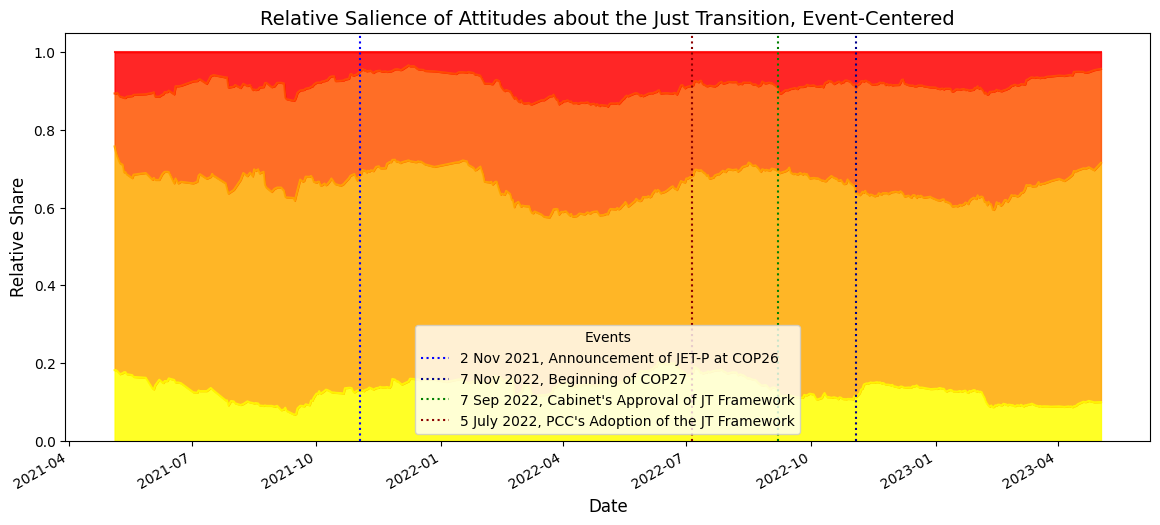

In [10]:
df_test["Date"] = pd.to_datetime(df_test["Date"])

df = df_test

df_grouped_abs = df.groupby(["Date", "Classification_Run_3"]).size().unstack(fill_value=0)

df_absolute_rolling = df_grouped_abs.rolling("90D", min_periods=1).sum()

df_relative_rolling = df_absolute_rolling.div(df_absolute_rolling.sum(axis=1), axis=0)

event_dates = {
    "2 Nov 2021, Announcement of JET-P at COP26": "2021-11-02",
    "7 Nov 2022, Beginning of COP27": "2022-11-03",
    "7 Sep 2022, Cabinet's Approval of JT Framework": "2022-09-07",
    "5 July 2022, PCC's Adoption of the JT Framework": "2022-07-05",
}

start_date = pd.Timestamp(min(event_dates.values())) - pd.DateOffset(months=6)
end_date = pd.Timestamp(max(event_dates.values())) + pd.DateOffset(months=6)

df_relative_filtered = df_relative_rolling[(df_relative_rolling.index >= start_date) & (df_relative_rolling.index <= end_date)]

fig, ax = plt.subplots(figsize=(14, 6))
df_relative_filtered.plot.area(ax=ax, colormap="autumn_r", alpha=0.85)

ax.set_title("Relative Salience of Attitudes about the Just Transition, Event-Centered", fontsize=14)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Relative Share", fontsize=12)
ax.legend("")

event_colors = {
    "2021-11-02": "blue",
    "2022-11-03": "darkblue",
    "2022-09-07": "green",
    "2022-07-05": "darkred",
}

event_legend_lines = []
for event, date in event_dates.items():
    event_date = pd.Timestamp(date)
    event_color = event_colors[date]
    ax.axvline(event_date, color=event_color, linestyle="dotted")
    event_legend_lines.append(mlines.Line2D([], [], color=event_color, linestyle="dotted", label=event))

ax.legend(handles=event_legend_lines, loc="lower center", title="Events")

plt.show()

Rescale all y axes to 0.6 for paper submission

C:\Users\charlott\AppData\Local\Temp\ipykernel_492\3602559297.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("autumn_r", num_categories)


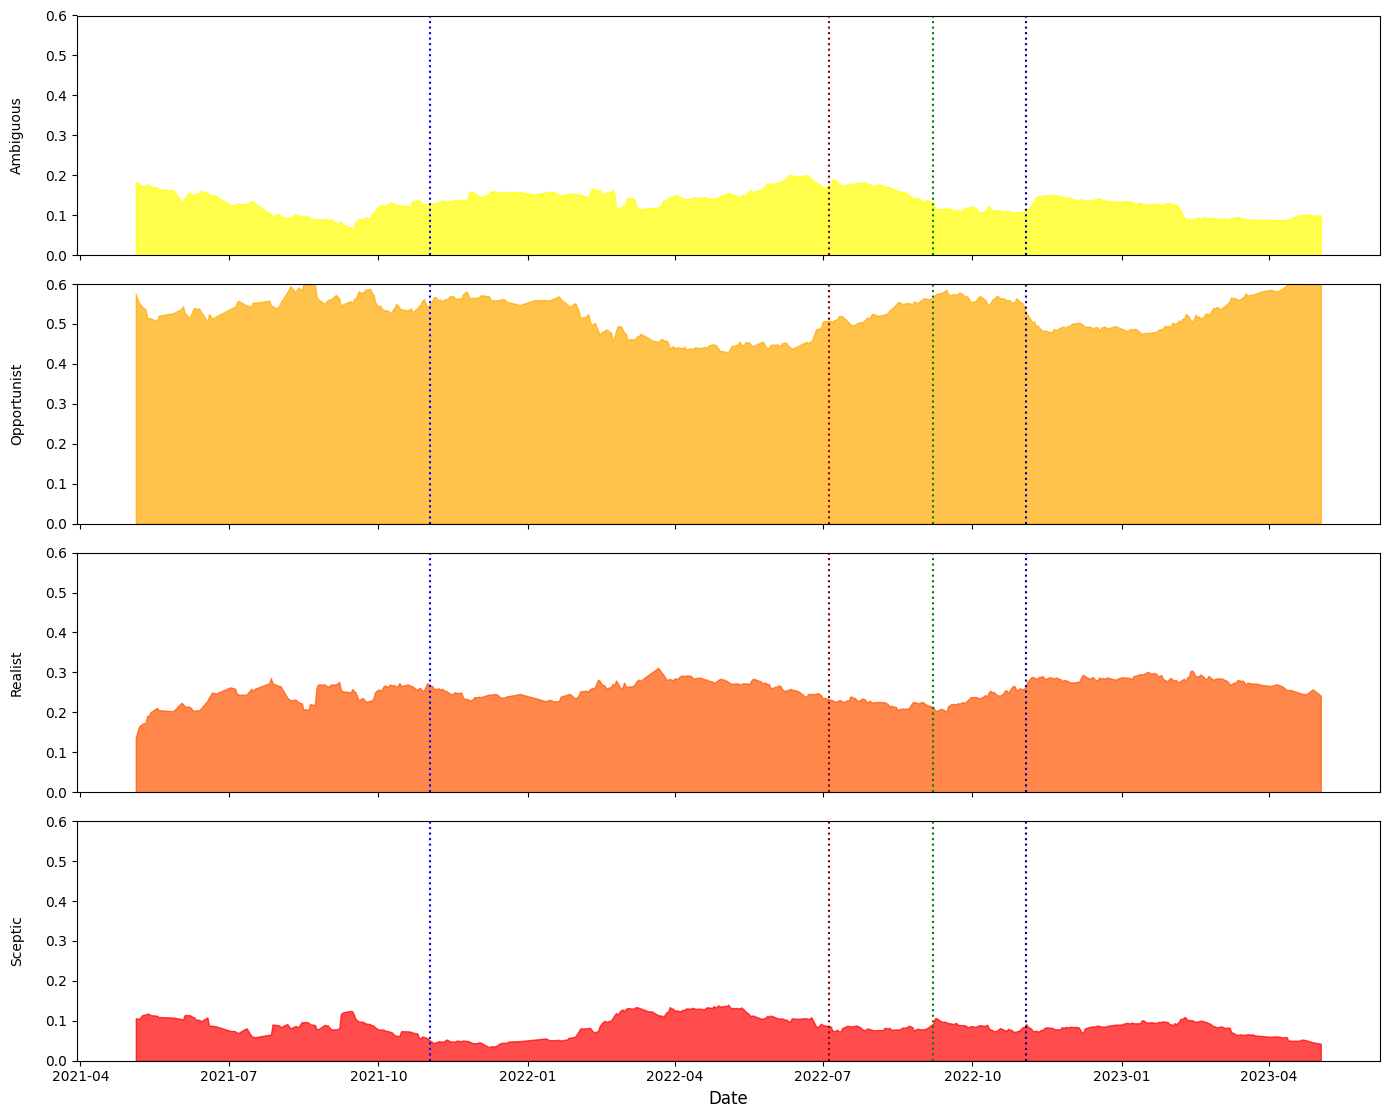

In [11]:
num_categories = len(df_relative_filtered.columns)
colormap = cm.get_cmap("autumn_r", num_categories)
colors = [mcolors.to_hex(colormap(i)) for i in range(num_categories)]

category_colors = {category: colors[i] for i, category in enumerate(df_relative_filtered.columns)}

fig, axes = plt.subplots(nrows=num_categories, figsize=(14, 12), sharex=True)

for ax, (category, data), color in zip(axes, df_relative_filtered.items(), colors):
    ax.fill_between(df_relative_filtered.index, data, color=color, alpha=0.7)
    ax.set_ylabel(category, fontsize=10, rotation=90, labelpad=15)
    ax.set_ylim(0, 0.6)

    for event, date in event_dates.items():
        event_date = pd.Timestamp(date)
        event_color = event_colors[date]
        ax.axvline(event_date, color=event_color, linestyle="dotted")

axes[-1].set_xlabel("Date", fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

C:\Users\charlott\AppData\Local\Temp\ipykernel_492\4132336491.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("autumn_r", num_categories)


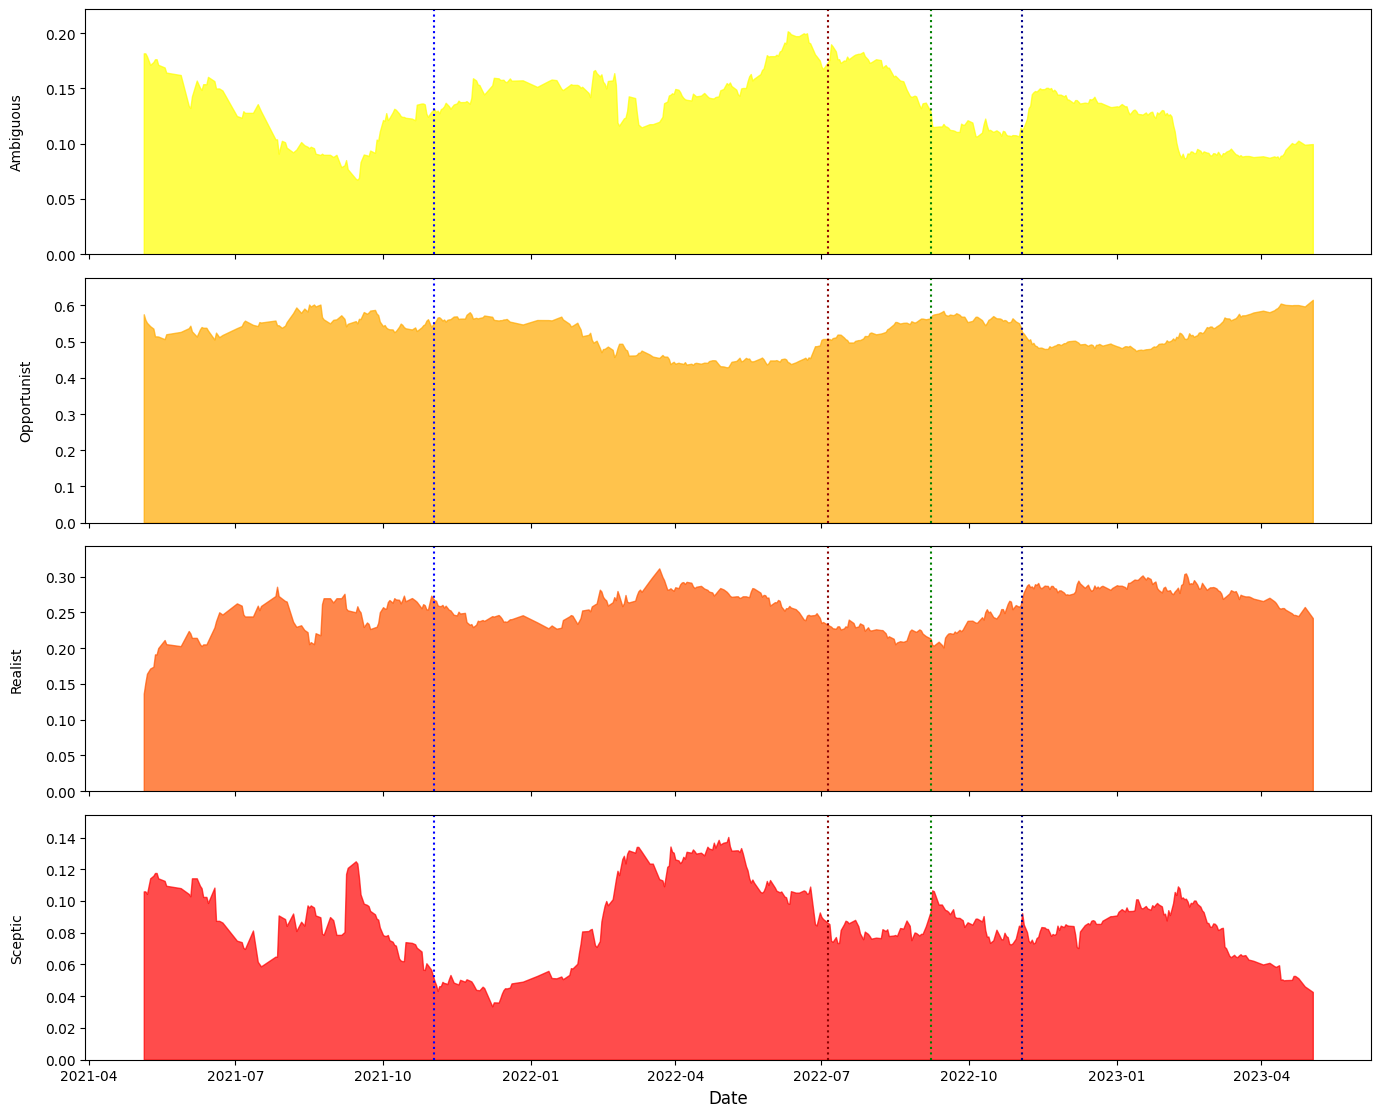

In [13]:
num_categories = len(df_relative_filtered.columns)
colormap = cm.get_cmap("autumn_r", num_categories)
colors = [mcolors.to_hex(colormap(i)) for i in range(num_categories)]

category_colors = {category: colors[i] for i, category in enumerate(df_relative_filtered.columns)}

fig, axes = plt.subplots(nrows=num_categories, figsize=(14, 12), sharex=True)

for ax, (category, data), color in zip(axes, df_relative_filtered.items(), colors):
    ax.fill_between(df_relative_filtered.index, data, color=color, alpha=0.7)
    ax.set_ylabel(category, fontsize=10, rotation=90, labelpad=15)
    ax.set_ylim(0, data.max() * 1.1)

    for event, date in event_dates.items():
        event_date = pd.Timestamp(date)
        event_color = event_colors[date]
        ax.axvline(event_date, color=event_color, linestyle="dotted")

axes[-1].set_xlabel("Date", fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()